In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load CSV files
links = pd.read_csv("links.csv")
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")

In [5]:
print("Movies Data:")
print(movies.head())  

print("\nRatings Data:")
print(ratings.head())

print("\nLinks Data:")
print(links.head())

print("\nTags Data:")
print(tags.head())

print("Movies columns:", movies.columns)
print("Ratings shape:", ratings.shape)

Movies Data:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings Data:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Links Data:
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  3135

In [9]:
movies.isnull().sum()
links.isnull().sum()
ratings.isnull().sum()
tags.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [10]:
movies.info()
links.info()
ratings.info()
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int

In [12]:
movies.shape
links.shape
ratings.shape
tags.shape

(3683, 4)

In [13]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [14]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [15]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [16]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [17]:
# For example, links.csv has imdbId and tmdbId which may not be needed initially
links = links.drop(columns=['imdbId', 'tmdbId'], errors='ignore')

In [18]:
print(movies.duplicated().sum())
print(ratings.duplicated().sum())

0
0


In [19]:
print(movies.isnull().sum())
print(ratings.isnull().sum())
print(tags.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


In [20]:
print(movies['genres'].unique())

<StringArray>
['Adventure|Animation|Children|Comedy|Fantasy',
                  'Adventure|Children|Fantasy',
                              'Comedy|Romance',
                        'Comedy|Drama|Romance',
                                      'Comedy',
                       'Action|Crime|Thriller',
                          'Adventure|Children',
                                      'Action',
                   'Action|Adventure|Thriller',
                               'Comedy|Horror',
 ...
    'Action|Adventure|Fantasy|Horror|Thriller',
                           'Comedy|Sci-Fi|War',
             'Comedy|Mystery|Romance|Thriller',
               'Fantasy|Horror|Sci-Fi|Western',
                       'Animation|Crime|Drama',
           'Adventure|Mystery|Sci-Fi|Thriller',
                  'Action|Comedy|Crime|Horror',
            'Action|Adventure|Children|Sci-Fi',
      'Action|Adventure|Comedy|Fantasy|Sci-Fi',
             'Action|Animation|Comedy|Fantasy']
Length: 951, dtype: s

In [21]:
genre_counts = movies['genres'].value_counts()
print(genre_counts)

genres
Drama                                     1053
Comedy                                     946
Comedy|Drama                               435
Comedy|Romance                             363
Drama|Romance                              349
                                          ... 
Adventure|Mystery|Sci-Fi|Thriller            1
Action|Comedy|Crime|Horror                   1
Action|Adventure|Children|Sci-Fi             1
Action|Adventure|Comedy|Fantasy|Sci-Fi       1
Action|Animation|Comedy|Fantasy              1
Name: count, Length: 951, dtype: int64


In [22]:
print(ratings['rating'].describe())

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


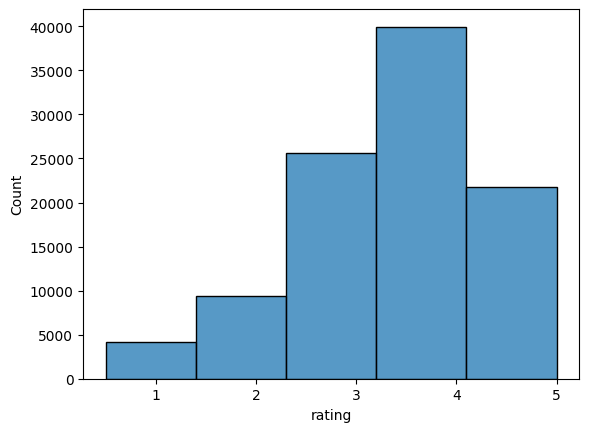

In [26]:
import seaborn as sns
sns.histplot(data=ratings, x='rating', bins=5, kde=False)
plt.show()

In [27]:
movie_ratings = ratings.merge(movies, on='movieId')
print(movie_ratings.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


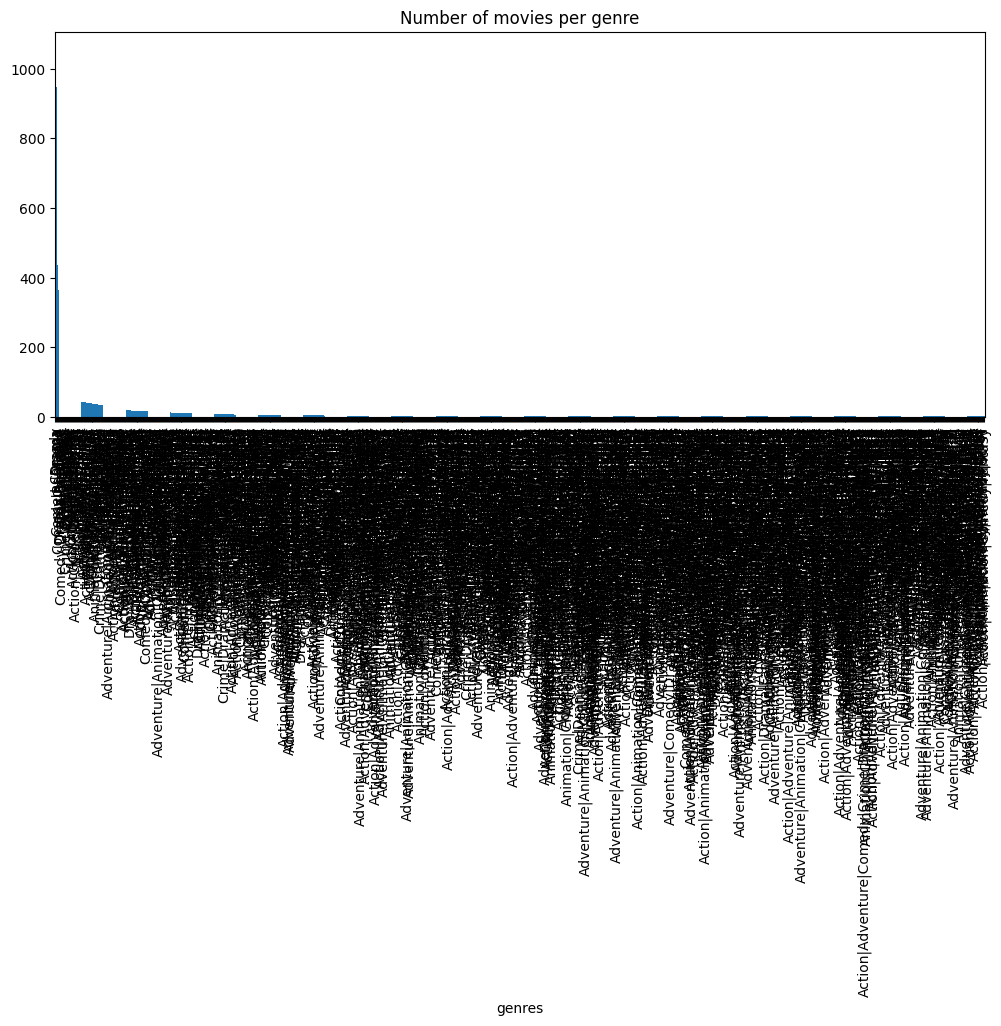

In [28]:
plt.figure(figsize=(12,5))
genre_counts.plot(kind='bar')
plt.title("Number of movies per genre")
plt.show()

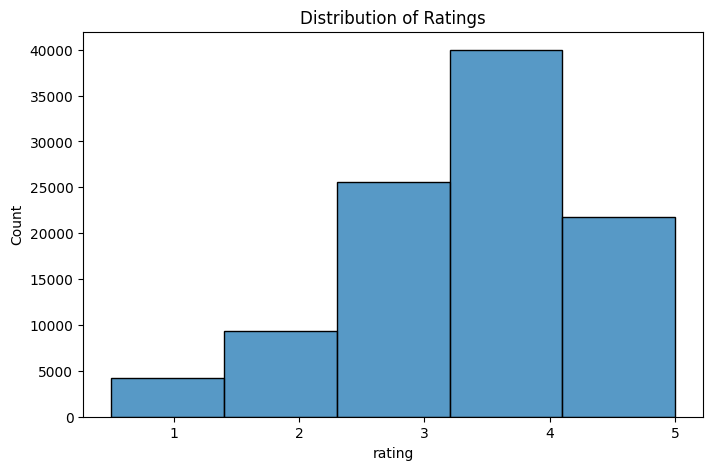

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=5, kde=False)
plt.title("Distribution of Ratings")
plt.show()

In [30]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['mean', 'count'])
print(movie_stats.head())

             mean  count
movieId                 
1        3.920930    215
2        3.431818    110
3        3.259615     52
4        2.357143      7
5        3.071429     49


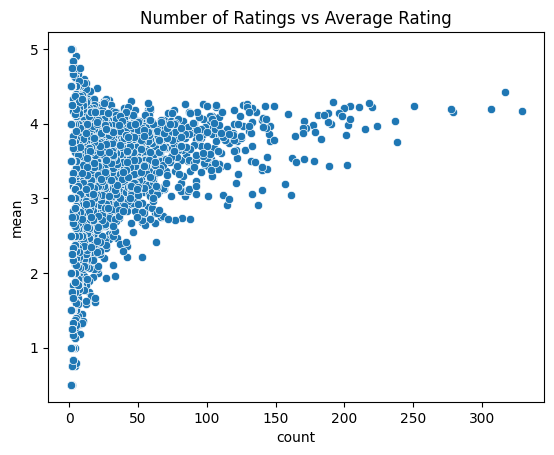

In [31]:
sns.scatterplot(x='count', y='mean', data=movie_stats)
plt.title("Number of Ratings vs Average Rating")
plt.show()